In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Load the Dataset 

In [3]:
ratings = pd.read_csv(
    "../data/raw/u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

# Genres
genre_cols = [
    "unknown", "Action", "Adventure", "Animation", "Children's", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror",
    "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"
]

# Movies
movies = pd.read_csv(
    "../data/raw/u.item",
    sep="|",
    encoding="latin-1",
    header=None,
    usecols=[0, 1] + list(range(5, 24))
)

movies.columns = ["movie_id", "title"] + genre_cols # rename the relevant columns

def extract_genres(row):
    return "|".join([genre for genre in genre_cols if row[genre] == 1])

movies["genres"] = movies.apply(extract_genres, axis=1)

In [7]:
ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [23]:
movies.head()

,movie_id,title,unknown,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,genres
0,1,Toy Story (1995),0,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,Animation|Children's|Comedy
1,2,GoldenEye (1995),0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,Action|Adventure|Thriller
2,3,Four Rooms (1995),0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,Thriller
3,4,Get Shorty (1995),0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,Action|Comedy|Drama
4,5,Copycat (1995),0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,Crime|Drama|Thriller


## Rating Distribution

In [9]:
print(ratings.shape)        # how many ratings total
print(ratings.nunique())    # unique users, movies
print(ratings.describe())   # min/max/mean rating, spot anomalies

(100000, 4)
user_id        943
movie_id      1682
rating           5
timestamp    49282
dtype: int64
            user_id       movie_id         rating     timestamp
count  100000.00000  100000.000000  100000.000000  1.000000e+05
mean      462.48475     425.530130       3.529860  8.835289e+08
std       266.61442     330.798356       1.125674  5.343856e+06
min         1.00000       1.000000       1.000000  8.747247e+08
25%       254.00000     175.000000       3.000000  8.794487e+08
50%       447.00000     322.000000       4.000000  8.828269e+08
75%       682.00000     631.000000       4.000000  8.882600e+08
max       943.00000    1682.000000       5.000000  8.932866e+08


<Axes: xlabel='rating'>

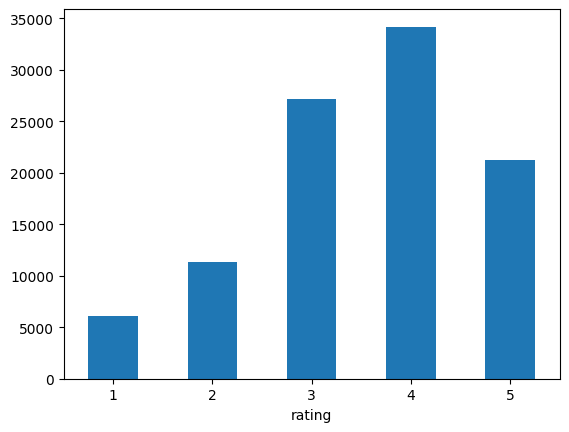

In [20]:
ratings["rating"].value_counts().sort_index().plot(kind="bar", rot="horizontal")

From the descriptive statistics and plot above, we can see that the median rating is 4 out of 5, and the 25th percentile is 3. This indicates a positive rating bias as users are more likely to rate movies they enjoy, and some users tend to rate everything generously while others are more critical. To correct for this, we apply mean-centering by subtracting each user's average rating from their individual ratings. This ensures that cosine similarity captures relative preference (how much a user likes a movie compared to their own average) rather than raw rating magnitude.

## Sparsity

In [11]:
n_users = ratings["user_id"].nunique()
n_movies = ratings["movie_id"].nunique()
n_ratings = len(ratings)

sparsity = 1 - (n_ratings / (n_users * n_movies))
print(f"Sparsity: {sparsity:.4%}")   # expect ~98–99% sparse

Sparsity: 93.6953%


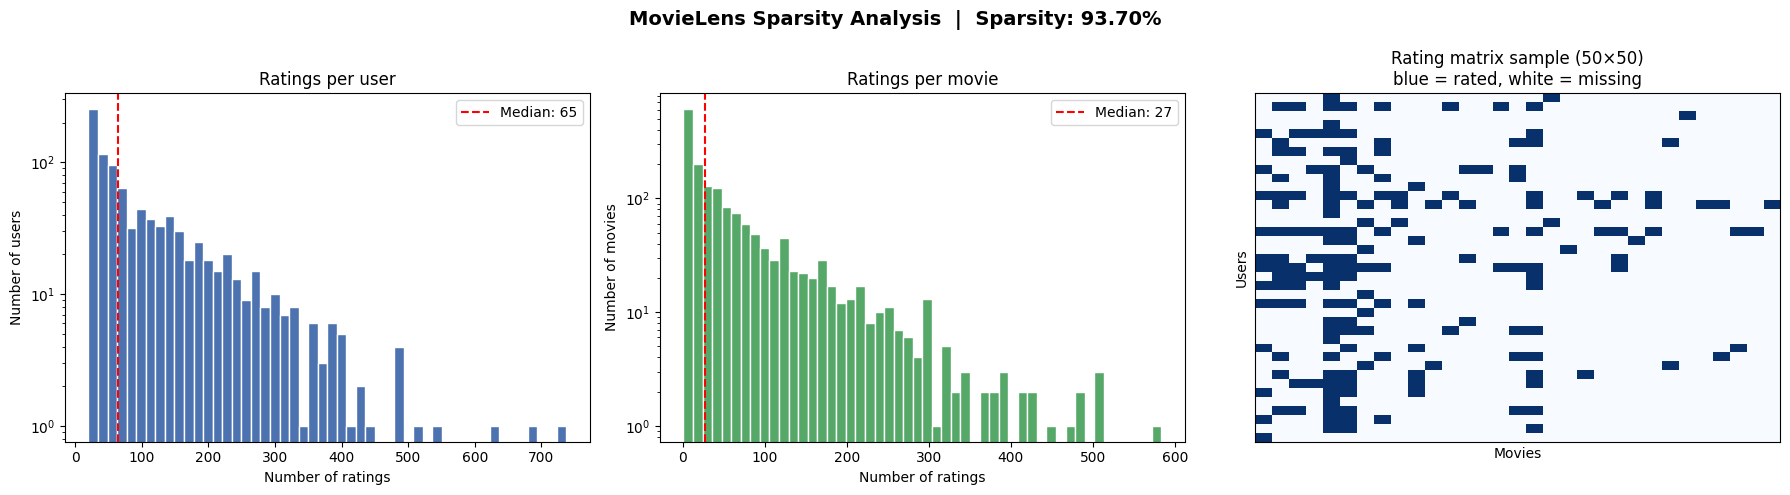

In [ ]:
# Calculate sparsity
n_users  = ratings["user_id"].nunique()
n_movies = ratings["movie_id"].nunique()
n_ratings = len(ratings)
sparsity = 1 - (n_ratings / (n_users * n_movies)) # 1 - density

ratings_per_user  = ratings.groupby("user_id").size()
ratings_per_movie = ratings.groupby("movie_id").size()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"MovieLens Sparsity Analysis  |  Sparsity: {sparsity:.2%}", fontsize=14, fontweight="bold")

# Ratings per user 
axes[0].hist(ratings_per_user, bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("Ratings per user")
axes[0].set_xlabel("Number of ratings")
axes[0].set_ylabel("Number of users")
axes[0].set_yscale("log")
axes[0].axvline(ratings_per_user.median(), color="red", linestyle="--", label=f"Median: {ratings_per_user.median():.0f}")
axes[0].legend()

# Ratings per movie 
axes[1].hist(ratings_per_movie, bins=50, color="#55A868", edgecolor="white")
axes[1].set_title("Ratings per movie")
axes[1].set_xlabel("Number of ratings")
axes[1].set_ylabel("Number of movies")
axes[1].set_yscale("log")
axes[1].axvline(ratings_per_movie.median(), color="red", linestyle="--", label=f"Median: {ratings_per_movie.median():.0f}")
axes[1].legend()

# Sparsity heatmap
sample_users  = np.random.choice(ratings["user_id"].unique(),  size=min(50, n_users),  replace=False)
sample_movies = np.random.choice(ratings["movie_id"].unique(), size=min(50, n_movies), replace=False)

sample = ratings[ratings["user_id"].isin(sample_users) & ratings["movie_id"].isin(sample_movies)]
matrix = sample.pivot(index="user_id", columns="movie_id", values="rating")

im = axes[2].imshow(~matrix.isna(), cmap="Blues", aspect="auto", interpolation="none")
axes[2].set_title("Rating matrix sample (50×50)\nblue = rated, white = missing")
axes[2].set_xlabel("Movies")
axes[2].set_ylabel("Users")
axes[2].set_xticks([])
axes[2].set_yticks([])

plt.tight_layout()
plt.savefig("sparsity_analysis.png", dpi=150)
plt.show()

Since sparsity is 93.7%, the dataset is highly sparse, making it suitable to apply SVD to decompose the user-item matrix into latent factors before computing mean-centered cosine similarity. Additionally, the median number of ratings per user is 63, while the median number of ratings per movie is 27, meaning half of all movies have fewer than 27 ratings. The relatively low number of ratings per movie may weaken the reliability of similarity scores, particularly for less popular movies. Hence, we will apply a minimum ratings threshold before generating recommendations. 

## Genre Distribution

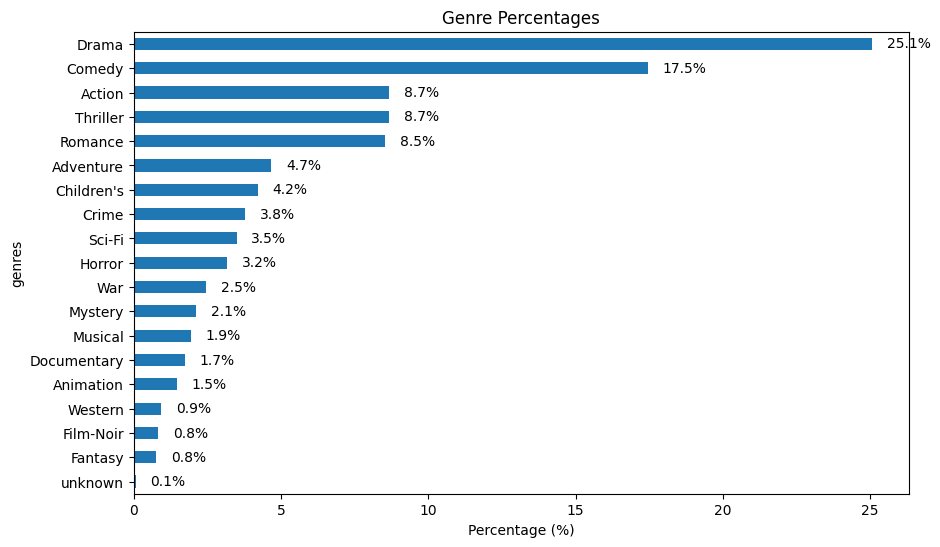

In [27]:
genre_counts = movies["genres"].str.split("|").explode().value_counts(normalize=True) * 100

ax = genre_counts.sort_values().plot(kind="barh", figsize=(10, 6))

for i, v in enumerate(genre_counts.sort_values()):
    ax.text(v + 0.5, i, f'{v:.1f}%', color='black', va='center')

plt.title("Genre Percentages")
plt.xlabel("Percentage (%)")
plt.show()

In [29]:
# Movies with only Drama as genre
single_drama = movies[movies["genres"] == "Drama"]
print(f"Pure Drama movies: {len(single_drama)}")

# Movies with multi-genres
multi_drama = movies[movies["genres"].str.contains("Drama") & movies["genres"].str.contains("|", regex=False)]
print(f"Drama + other genres: {len(multi_drama)}")

Pure Drama movies: 376
Drama + other genres: 349


Drama and Comedy are the most frequently assigned genre tags, accounting for 25.1% and 17.5% of all tags respectively. Together, the top five genres: Drama, Comedy, Action, Thriller, and Romance - account for approximately 68% of all genre tags. In contrast, niche genres such as Fantasy and Film-Noir each represent only 0.8% of all tags, indicating a heavily skewed genre distribution. This imbalance means that common genres like Drama are weak signals of user preference, as almost any movie could be labelled as Drama, while rarer genres like Sci-Fi or Film-Noir are far more distinctive. We therefore apply Inverse Document Frequency (IDF) weighting to genre scores, which downweights common genres and amplifies the contribution of rare ones when building a user's genre preference profile. 

In [47]:
# Movies where unknown is a genre
unknown = movies[movies["genres"].apply(lambda x: "unknown" in x)]
print(f"Movies with 'unknown' genre: {len(unknown)}")
print(unknown[["movie_id", "title", "genres"]])

Movies with 'unknown' genre: 2
      movie_id                title   genres
266        267              unknown  unknown
1372      1373  Good Morning (1971)  unknown


We remove movies tagged with unknown as it is not a meaningful genre label and would produce uninformative IDF weights. Movies where unknown is the only genre tag are dropped entirely, as they cannot contribute to genre-based scoring. For movies where unknown appears alongside valid genres, the tag is stripped and the remaining genres are retained.

## Number of Components, K

Text(0, 0.5, 'Cumulative variance explained')

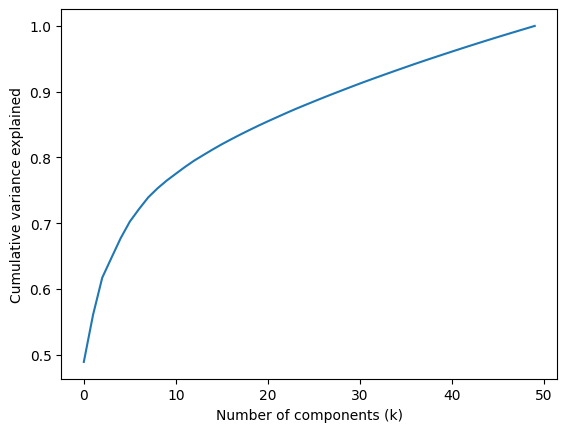

In [31]:
from scipy.sparse.linalg import svds
from scipy.sparse import csr_matrix
import numpy as np

matrix = ratings.pivot(index="user_id", columns="movie_id", values="rating").fillna(0)
sparse = csr_matrix(matrix.values)

U, sigma, Vt = svds(sparse, k=50)
explained = np.cumsum(sigma[::-1]**2) / np.sum(sigma**2)
plt.plot(explained)
plt.xlabel("Number of components (k)")
plt.ylabel("Cumulative variance explained")

We selected k=20 latent factors for SVD based on the cumulative variance explained plot. At k=20, approximately 85% of the variance in the user-item matrix is captured, which we determined to be a sufficient threshold for this dataset. 

While higher values of k capture more variance, the matrix sparsity of 93.7% means that additional components beyond k=20 risk modelling noise from missing ratings rather than genuine user preference patterns. Given the relatively small scale of the dataset (~1,700 movies, ~1,000 users), k=20 strikes a balance between capturing meaningful latent structure and avoiding overfitting to the sparse regions of the matrix.